In [1]:
# These are pre-installed in Colab, just import them
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("All good!")

All good!


In [5]:
import zipfile
import os

# Unzip the file
with zipfile.ZipFile("ipl dataset.zip", "r") as z:
    z.extractall("ipl_data")

# See what files are inside
os.listdir("ipl_data")

['deliveries.csv', 'matches.csv']

In [6]:
df = pd.read_csv("ipl_data/matches.csv")

print(df.shape)
df.head()

(756, 18)


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [7]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

Shape: (756, 18)

Columns: ['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']

Missing values:
 id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64


/tmp/ipykernel_2976/852566933.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_counts.index, y=win_counts.values, palette="viridis")


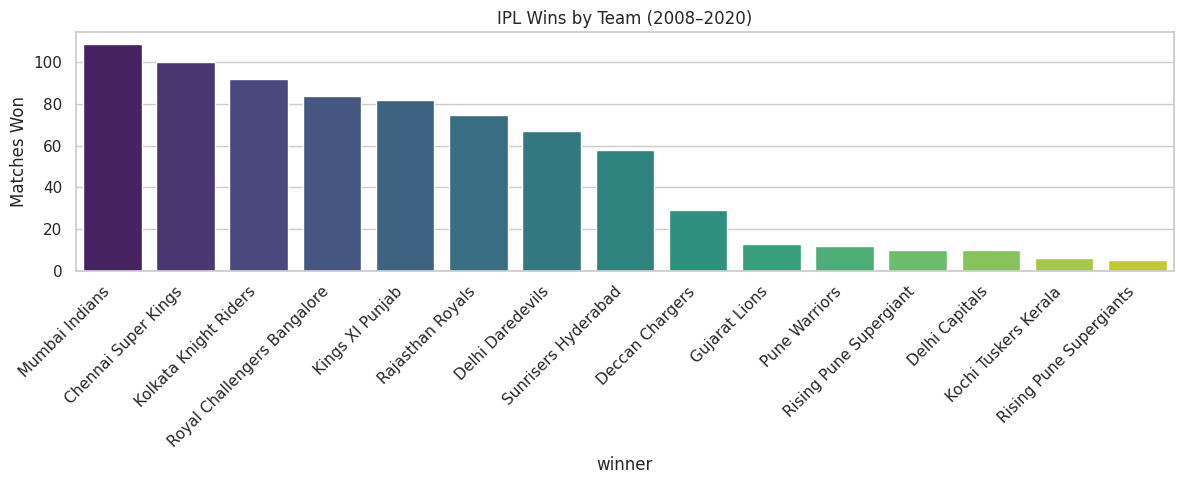

In [8]:
plt.figure(figsize=(12, 5))
win_counts = df['winner'].value_counts()
sns.barplot(x=win_counts.index, y=win_counts.values, palette="viridis")
plt.title("IPL Wins by Team (2008–2020)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Matches Won")
plt.tight_layout()
plt.show()

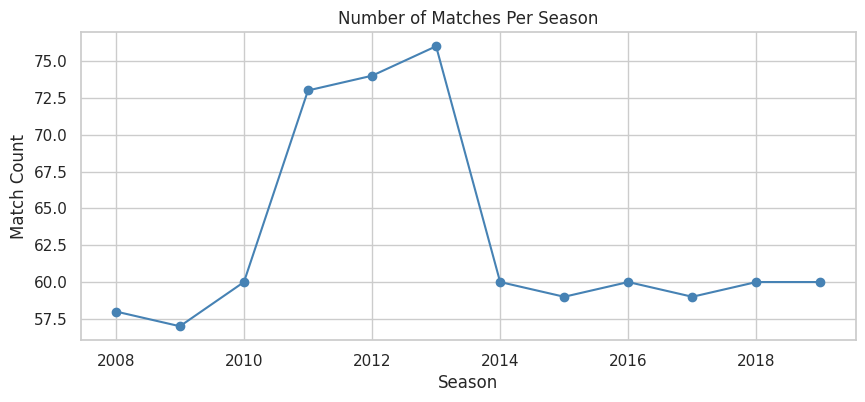

In [9]:
plt.figure(figsize=(10, 4))
df.groupby('season')['id'].count().plot(kind='line', marker='o', color='steelblue')
plt.title("Number of Matches Per Season")
plt.xlabel("Season")
plt.ylabel("Match Count")
plt.show()

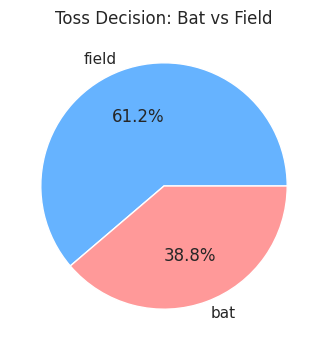

In [10]:
plt.figure(figsize=(6, 4))
df['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title("Toss Decision: Bat vs Field")
plt.ylabel("")
plt.show()

/tmp/ipykernel_2976/3692953730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_venues.values, y=top_venues.index, palette="magma")


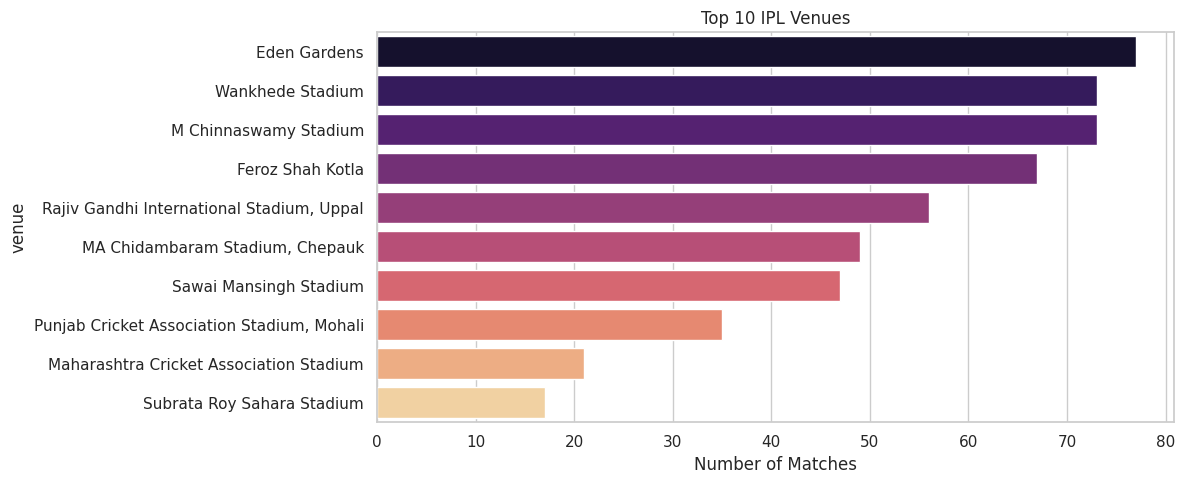

In [11]:
plt.figure(figsize=(12, 5))
top_venues = df['venue'].value_counts().head(10)
sns.barplot(x=top_venues.values, y=top_venues.index, palette="magma")
plt.title("Top 10 IPL Venues")
plt.xlabel("Number of Matches")
plt.tight_layout()
plt.show()

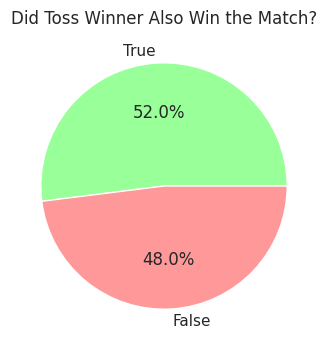

In [12]:
df['toss_match_win'] = df['toss_winner'] == df['winner']

plt.figure(figsize=(6, 4))
df['toss_match_win'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#99ff99','#ff9999'])
plt.title("Did Toss Winner Also Win the Match?")
plt.ylabel("")
plt.show()